In [89]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import sklearn.linear_model as skl

In [90]:
train_latents= np.load('../cache/thingseeg2_extracted_embeddings/train_clip.npy')
test_latents = np.load('../cache/thingseeg2_extracted_embeddings/test_clip.npy')
test_concepts = np.load('../data/thingseeg2_metadata/test_concepts.npy')
train_latents_mean = np.mean(train_latents,axis=0)
train_latents_std = np.std(train_latents,axis=0)
train_latents_whitened = (train_latents - train_latents_mean) / train_latents_std
test_latents_whitened = (test_latents - train_latents_mean) / train_latents_std
# test_latents_mean = np.mean(test_latents,axis=0)
# test_latents_std = np.std(test_latents,axis=0)
# test_latents_whitened = (test_latents - test_latents_mean) / test_latents_std
print(train_latents.shape, test_latents.shape)

from scipy.spatial.distance import pdist, squareform
dist_test_latents = pdist(test_latents, metric='euclidean')
dist_test_latents_whitened = pdist(test_latents_whitened, metric='euclidean')
print(dist_test_latents.shape, dist_test_latents_whitened.shape)
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list
linkage_data = linkage(dist_test_latents_whitened, method='ward', metric='euclidean')
print(linkage_data.shape)
leaves = leaves_list(linkage_data)
labels = [f"{leaf}-{test_concepts[leaf]}" for leaf in range(len(leaves))]

(16540, 1024) (200, 1024)
(19900,) (19900,)
(199, 4)


In [96]:
eeg_whitened_all_subs = []
new_w_pred_all_subs_clip = []
new_w_pred_whitened_all_subs_clip = []
saliency_all_subs_clip = []
saliency_whitened_all_subs_clip = []
saliency_renormed_all_subs_clip = []
all_subs_corr_eeg_whitened = []
all_subs_corr_new_w_pred_whitend = []
all_subs_corr_saliency = []
all_subs_corr_saliency_whitened = []
all_subs_corr_saliency_renormed = []
pred_latents_whitend_all_subs_clip = []
for sub in tqdm(range(1, 11), total=10):

    with open(f'../cache/thingseeg2_preproc/regression_weights/sub-{sub:02d}/regress-for-saliency_clip_weights.pkl',"rb") as f:
        datadict = pickle.load(f)
        reg_w_dec = datadict['weight'].T
        reg_b_dec = datadict['bias']
        reg_dec = skl.Ridge(alpha=1000, fit_intercept=True)
        reg_dec.coef_ = reg_w_dec.T
        reg_dec.intercept_ = reg_b_dec
    with open(f'../cache/thingseeg2_preproc/regression_weights/sub-{sub:02d}/regress-for-saliency-encode_clip_weights.pkl',"rb") as f:
        datadict = pickle.load(f)
        reg_w = datadict['weight'].T
        reg_b = datadict['bias']
        reg_enc = skl.Ridge(alpha=1000, fit_intercept=True)
        reg_enc.coef_ = reg_w.T
        reg_enc.intercept_ = reg_b

    train_latents= np.load('../cache/thingseeg2_extracted_embeddings/train_clip.npy')
    test_latents = np.load('../cache/thingseeg2_extracted_embeddings/test_clip.npy')
    test_concepts = np.load('../data/thingseeg2_metadata/test_concepts.npy')
    # print(train_latents.shape, test_latents.shape)

    train_latents_mean = np.mean(train_latents,axis=0)
    train_latents_std = np.std(train_latents,axis=0)
    test_latents_mean = np.mean(test_latents,axis=0)
    test_latents_std = np.std(test_latents,axis=0)
    train_latents_whitened = (train_latents - train_latents_mean) / train_latents_std
    test_latents_whitened_clip = (test_latents - train_latents_mean) / train_latents_std
    # new_w = test_latents @ reg_w
    # new_w_whitened = test_latents_whitened_clip @ reg_w

    eeg_train = np.load(f'../data/thingseeg2_preproc/sub-{sub:02d}/train_thingseeg2_avg.npy')
    eeg_test = np.load(f'../data/thingseeg2_preproc/sub-{sub:02d}/test_thingseeg2_avg.npy')
    eeg_train = eeg_train.reshape(eeg_train.shape[0],-1)
    eeg_test = eeg_test.reshape(eeg_test.shape[0],-1)
    # print(eeg_train.shape, eeg_test.shape)
    norm_mean_train = np.mean(eeg_train, axis=0)
    norm_scale_train = np.std(eeg_train, axis=0, ddof=1)
    eeg_train_whitened = (eeg_train - norm_mean_train) / norm_scale_train
    eeg_test_whitened = (eeg_test - norm_mean_train) / norm_scale_train

    pred_latents = np.load(f'../cache/thingseeg2_preproc/predicted_embeddings/sub-{sub:02d}/regress_clip.npy')
    pred_latents_whitened_clip = (pred_latents - train_latents_mean) / train_latents_std
    new_w_pred = pred_latents @ reg_w
    # new_w_pred = reg_enc.predict(pred_latents)
    new_w_pred_whitened = pred_latents_whitened_clip @ reg_w
    # new_w_pred_whitened = reg_enc.predict(pred_latents_whitened_clip)
    # print(new_w_pred.shape, new_w_pred_whitened.shape)
    # pred_latents_whitend_all_subs.append(pred_latents_whitened)
    eeg_whitened_all_subs.append(eeg_test_whitened)
    new_w_pred_all_subs_clip.append(new_w_pred)
    new_w_pred_whitened_all_subs_clip.append(new_w_pred_whitened)
    corr_eeg_whitened = np.corrcoef(eeg_test_whitened[leaves], rowvar=True)
    all_subs_corr_eeg_whitened.append(corr_eeg_whitened)
    pred_latents_whitend_all_subs_clip.append(pred_latents_whitened_clip)
    corr_new_w_pred_whitend = np.corrcoef(new_w_pred_whitened[leaves], rowvar=True)
    all_subs_corr_new_w_pred_whitend.append(corr_new_w_pred_whitend)

    pred_eeg = np.load(f'../cache/thingseeg2_preproc/predicted_embeddings/sub-{sub:02d}/regress-encode_clip.npy') # it's a prediction of the whitened EEG
    # saliency = pred_eeg @ reg_w_dec
    saliency = reg_dec.predict(pred_eeg)
    saliency_mean = saliency.mean(axis=0)
    saliency_std = saliency.std(axis=0)
    saliency_whitened = (saliency - saliency_mean) / saliency_std
    saliency_renormed = saliency_whitened * train_latents_std + train_latents_mean
    corr_saliency = np.corrcoef(saliency[leaves], rowvar=True)
    corr_saliency_whitened = np.corrcoef(saliency_whitened[leaves], rowvar=True)
    corr_saliency_renormed = np.corrcoef(saliency_renormed[leaves], rowvar=True)
    saliency_all_subs_clip.append(saliency)
    saliency_whitened_all_subs_clip.append(saliency_whitened)
    saliency_renormed_all_subs_clip.append(saliency_renormed)
    all_subs_corr_saliency.append(corr_saliency)
    all_subs_corr_saliency_whitened.append(corr_saliency_whitened)
    all_subs_corr_saliency_renormed.append(corr_saliency_renormed)

# pred_latents_whitened_all_subs_avg = np.mean(pred_latents_whitend_all_subs, axis=0)
# pred_latents_whitened_all_subs_avg = np.stack(pred_latents_whitend_all_subs, axis=0).mean(axis=0)
eeg_whitened_all_subs_avg = np.stack(eeg_whitened_all_subs, axis=0).mean(axis=0)
new_w_pred_all_subs_clip = np.stack(new_w_pred_all_subs_clip, axis=0)#.mean(axis=0)
new_w_pred_all_subs_clip_avg = new_w_pred_all_subs_clip.mean(axis=0)
new_w_pred_whitened_all_subs_clip = np.stack(new_w_pred_whitened_all_subs_clip, axis=0)#.mean(axis=0)
new_w_pred_whitened_all_subs_clip_avg = new_w_pred_whitened_all_subs_clip.mean(axis=0)
saliency_all_subs_clip = np.stack(saliency_all_subs_clip, axis=0)#.mean(axis=0)
saliency_all_subs_clip_avg = saliency_all_subs_clip.mean(axis=0)
saliency_whitened_all_subs_clip = np.stack(saliency_whitened_all_subs_clip, axis=0)#.mean(axis=0)
saliency_whitened_all_subs_clip_avg = saliency_whitened_all_subs_clip.mean(axis=0)
saliency_renormed_all_subs_clip = np.stack(saliency_renormed_all_subs_clip, axis=0)#.mean(axis=0)
saliency_renormed_all_subs_clip_avg = saliency_renormed_all_subs_clip.mean(axis=0)

all_subs_avg_corr_eeg_whitened = np.stack(all_subs_corr_eeg_whitened, axis=0).mean(axis=0)
all_subs_avg_corr_new_w_pred_whitend = np.stack(all_subs_corr_new_w_pred_whitend, axis=0).mean(axis=0)
all_subs_corr_saliency = np.stack(all_subs_corr_saliency, axis=0)#.mean(axis=0)
all_subs_corr_saliency_whitened = np.stack(all_subs_corr_saliency_whitened, axis=0)#.mean(axis=0)
all_subs_corr_saliency_renormed = np.stack(all_subs_corr_saliency_renormed, axis=0)#.mean(axis=0)
all_subs_avg_corr_saliency_whitened = all_subs_corr_saliency_whitened.mean(axis=0)
all_subs_avg_corr_saliency = all_subs_corr_saliency.mean(axis=0)
corr_saliency_all_subs_avg = np.corrcoef(saliency_all_subs_clip_avg[leaves], rowvar=True)
corr_saliency_whitened_all_subs_avg = np.corrcoef(saliency_whitened_all_subs_clip_avg[leaves], rowvar=True)
# print(eeg_whitened_all_subs_avg.shape, all_subs_avg_corr_eeg_whitened.shape)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:05<00:00,  1.94it/s]


In [4]:
all_subs_avg_corr_new_w_pred_whitend.shape

(200, 200)

In [5]:
# sub = 1
# corr_new_w_pred = np.corrcoef(new_w_pred_whitened_all_subs_clip[sub - 1][leaves], rowvar=True)
# plt.figure(figsize=(8, 6), dpi=80) # 300
# plt.imshow(corr_new_w_pred, cmap='coolwarm', vmin=-0.8, vmax=0.8, interpolation='none')
# plt.colorbar()
# for i in [106, 106+37]:
#     plt.axhline(y=i-0.5, color='black', linestyle='--', linewidth=0.8)
#     plt.axvline(x=i-0.5, color='black', linestyle='--', linewidth=0.8)
# plt.title(f'RSA of CLIP-filtered EEG Patterns (sub-{sub:02d})');

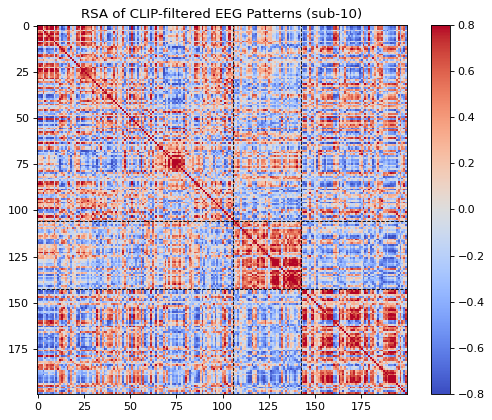

In [41]:
sub = 10
plt.figure(figsize=(8, 6), dpi=80) # 300
plt.imshow(all_subs_corr_new_w_pred_whitend[sub - 1], cmap='coolwarm', vmin=-0.8, vmax=0.8, interpolation='none')
plt.colorbar()
for i in [106, 106+37]:
    plt.axhline(y=i-0.5, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=i-0.5, color='black', linestyle='--', linewidth=0.8)
plt.title(f'RSA of CLIP-filtered EEG Patterns (sub-{sub:02d})');

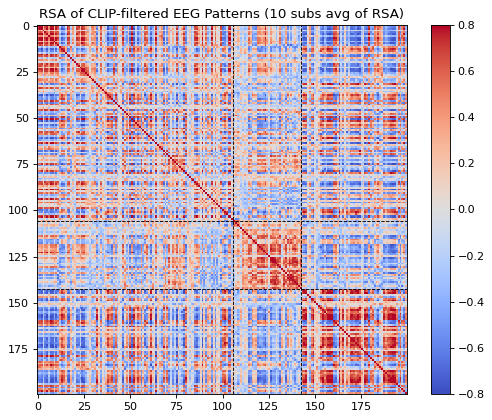

In [42]:
plt.figure(figsize=(8, 6), dpi=80) # 300
plt.imshow(all_subs_avg_corr_new_w_pred_whitend, cmap='coolwarm', vmin=-0.8, vmax=0.8, interpolation='none')
plt.colorbar()
for i in [106, 106+37]:
    plt.axhline(y=i-0.5, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=i-0.5, color='black', linestyle='--', linewidth=0.8)
plt.title(f'RSA of CLIP-filtered EEG Patterns (10 subs avg of RSA)');

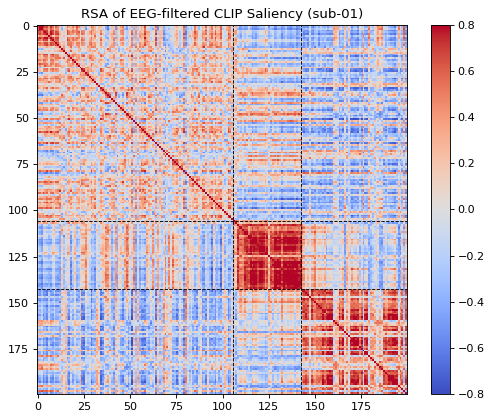

In [50]:
sub = 1
plt.figure(figsize=(8, 6), dpi=80) # 300
plt.imshow(all_subs_corr_saliency[sub - 1], cmap='coolwarm', vmin=-0.8, vmax=0.8, interpolation='none')
plt.colorbar()
for i in [106, 106+37]:
    plt.axhline(y=i-0.5, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=i-0.5, color='black', linestyle='--', linewidth=0.8)
plt.title(f'RSA of EEG-filtered CLIP Saliency (sub-{sub:02d})');

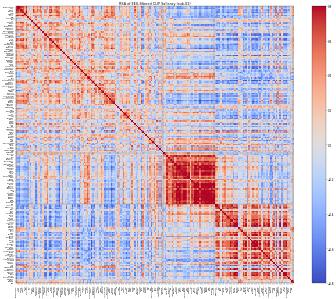

In [71]:
sub = 1
plt.figure(figsize=(8*3, 6*3), dpi=20) # 80
plt.imshow(all_subs_corr_saliency[sub - 1], cmap='coolwarm', vmin=-0.8, vmax=0.8, interpolation='none')
plt.colorbar()
for i in [106, 106+37]:
    plt.axhline(y=i-0.5, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=i-0.5, color='black', linestyle='--', linewidth=0.8)
# Set x and y axis labels
plt.xticks(ticks=range(len(test_concepts[leaves])), labels=test_concepts[leaves], rotation=90, fontsize=6)
plt.yticks(ticks=range(len(test_concepts[leaves])), labels=test_concepts[leaves], fontsize=6)
plt.title(f'RSA of EEG-filtered CLIP Saliency (sub-{sub:02d})');

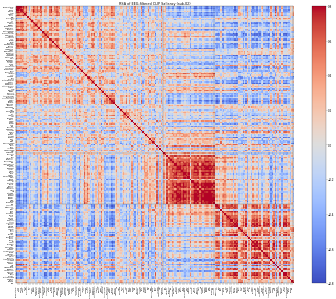

In [10]:
sub = 2
plt.figure(figsize=(8*3, 6*3), dpi=20) # 80
plt.imshow(all_subs_corr_saliency[sub - 1], cmap='coolwarm', vmin=-0.8, vmax=0.8, interpolation='none')
plt.colorbar()
for i in [106, 106+37]:
    plt.axhline(y=i-0.5, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=i-0.5, color='black', linestyle='--', linewidth=0.8)
# Set x and y axis labels
plt.xticks(ticks=range(len(test_concepts[leaves])), labels=test_concepts[leaves], rotation=90, fontsize=6)
plt.yticks(ticks=range(len(test_concepts[leaves])), labels=test_concepts[leaves], fontsize=6)
plt.title(f'RSA of EEG-filtered CLIP Saliency (sub-{sub:02d})');

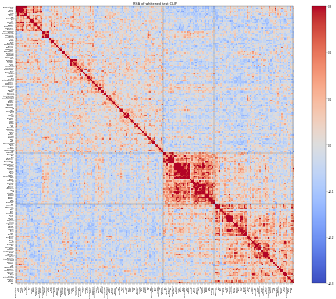

In [72]:
corr_test_latents_whitened = np.corrcoef(test_latents_whitened[leaves], rowvar=True)
plt.figure(figsize=(8*3, 6*3), dpi=20) # 80
plt.imshow(corr_test_latents_whitened, cmap='coolwarm', vmin=-0.3, vmax=0.3, interpolation='none')
plt.colorbar()
for i in [106, 106+37]:
    plt.axhline(y=i-0.5, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=i-0.5, color='black', linestyle='--', linewidth=0.8)
# Set x and y axis labels
plt.xticks(ticks=range(len(test_concepts[leaves])), labels=test_concepts[leaves], rotation=90, fontsize=6)
plt.yticks(ticks=range(len(test_concepts[leaves])), labels=test_concepts[leaves], fontsize=6)
plt.title(f'RSA of whitened test CLIP');

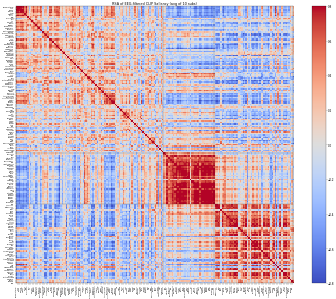

In [12]:
plt.figure(figsize=(8*3, 6*3), dpi=20) # 80
plt.imshow(corr_saliency_all_subs_avg, cmap='coolwarm', vmin=-0.8, vmax=0.8, interpolation='none')
plt.colorbar()
for i in [106, 106+37]:
    plt.axhline(y=i-0.5, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=i-0.5, color='black', linestyle='--', linewidth=0.8)
# Set x and y axis labels
plt.xticks(ticks=range(len(test_concepts[leaves])), labels=test_concepts[leaves], rotation=90, fontsize=6)
plt.yticks(ticks=range(len(test_concepts[leaves])), labels=test_concepts[leaves], fontsize=6)
plt.title(f'RSA of EEG-filtered CLIP Saliency (avg of 10 subs)');

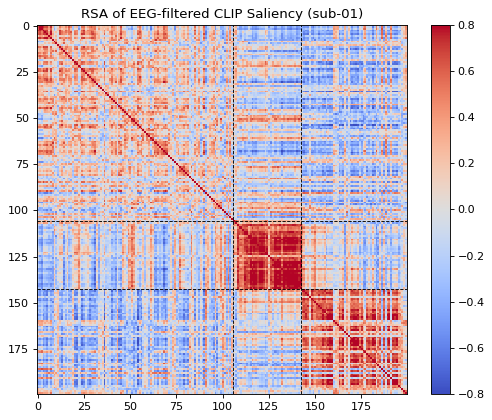

In [13]:
sub = 1
plt.figure(figsize=(8, 6), dpi=80) # 300
plt.imshow(all_subs_corr_saliency[sub - 1], cmap='coolwarm', vmin=-0.8, vmax=0.8, interpolation='none')
plt.colorbar()
for i in [106, 106+37]:
    plt.axhline(y=i-0.5, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=i-0.5, color='black', linestyle='--', linewidth=0.8)
plt.title(f'RSA of EEG-filtered CLIP Saliency (sub-{sub:02d})');

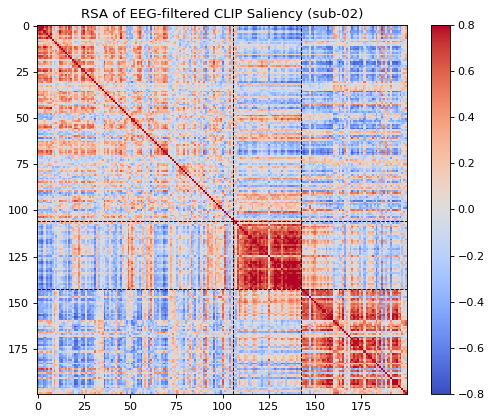

In [14]:
sub = 2
plt.figure(figsize=(8, 6), dpi=80) # 300
plt.imshow(all_subs_corr_saliency[sub - 1], cmap='coolwarm', vmin=-0.8, vmax=0.8, interpolation='none')
plt.colorbar()
for i in [106, 106+37]:
    plt.axhline(y=i-0.5, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=i-0.5, color='black', linestyle='--', linewidth=0.8)
plt.title(f'RSA of EEG-filtered CLIP Saliency (sub-{sub:02d})');

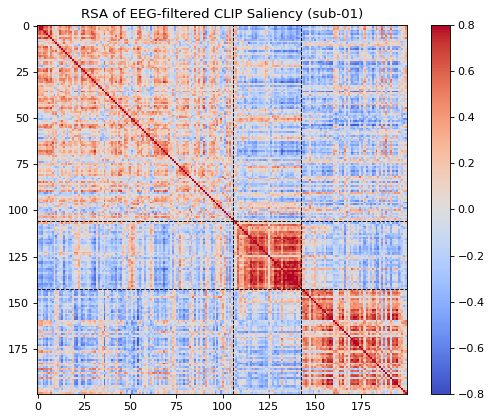

In [15]:
sub = 1
plt.figure(figsize=(8, 6), dpi=80) # 300
plt.imshow(all_subs_corr_saliency_whitened[sub - 1], cmap='coolwarm', vmin=-0.8, vmax=0.8, interpolation='none')
plt.colorbar()
for i in [106, 106+37]:
    plt.axhline(y=i-0.5, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=i-0.5, color='black', linestyle='--', linewidth=0.8)
plt.title(f'RSA of EEG-filtered CLIP Saliency (sub-{sub:02d})');

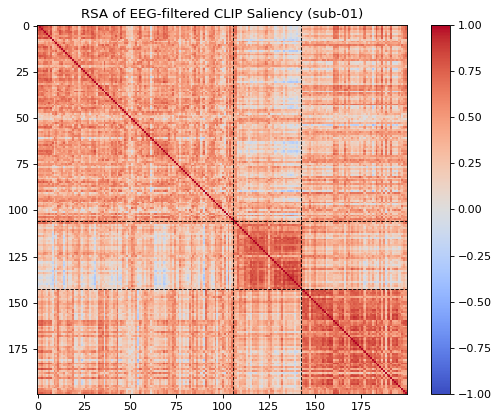

In [85]:
sub = 1
plt.figure(figsize=(8, 6), dpi=80) # 300
plt.imshow(all_subs_corr_saliency_renormed[sub - 1], cmap='coolwarm', vmin=-1, vmax=1, interpolation='none')
plt.colorbar()
for i in [106, 106+37]:
    plt.axhline(y=i-0.5, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=i-0.5, color='black', linestyle='--', linewidth=0.8)
plt.title(f'RSA of EEG-filtered CLIP Saliency (sub-{sub:02d})');

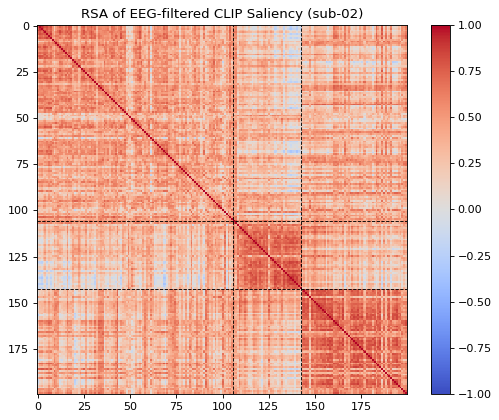

In [86]:
sub = 2
plt.figure(figsize=(8, 6), dpi=80) # 300
plt.imshow(all_subs_corr_saliency_renormed[sub - 1], cmap='coolwarm', vmin=-1, vmax=1, interpolation='none')
plt.colorbar()
for i in [106, 106+37]:
    plt.axhline(y=i-0.5, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=i-0.5, color='black', linestyle='--', linewidth=0.8)
plt.title(f'RSA of EEG-filtered CLIP Saliency (sub-{sub:02d})');

In [18]:
np.allclose(all_subs_corr_saliency[0], all_subs_corr_saliency[9])

False

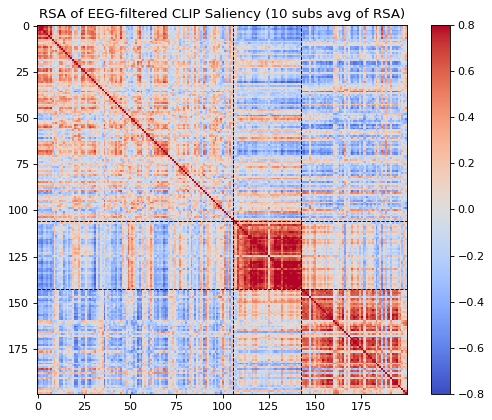

In [19]:
plt.figure(figsize=(8, 6), dpi=80) # 300
plt.imshow(all_subs_avg_corr_saliency, cmap='coolwarm', vmin=-0.8, vmax=0.8, interpolation='none')
plt.colorbar()
for i in [106, 106+37]:
    plt.axhline(y=i-0.5, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=i-0.5, color='black', linestyle='--', linewidth=0.8)
plt.title(f'RSA of EEG-filtered CLIP Saliency (10 subs avg of RSA)');

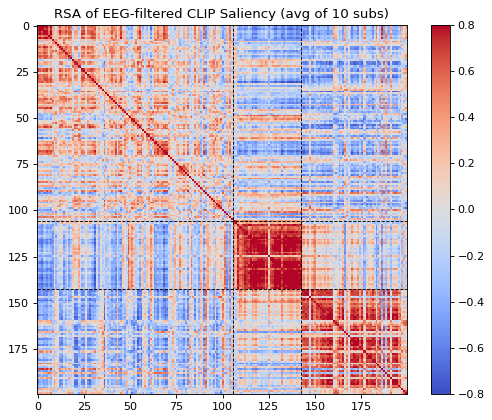

In [20]:
plt.figure(figsize=(8, 6), dpi=80) # 300
plt.imshow(corr_saliency_all_subs_avg, cmap='coolwarm', vmin=-0.8, vmax=0.8, interpolation='none')
plt.colorbar()
for i in [106, 106+37]:
    plt.axhline(y=i-0.5, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=i-0.5, color='black', linestyle='--', linewidth=0.8)
plt.title(f'RSA of EEG-filtered CLIP Saliency (avg of 10 subs)');

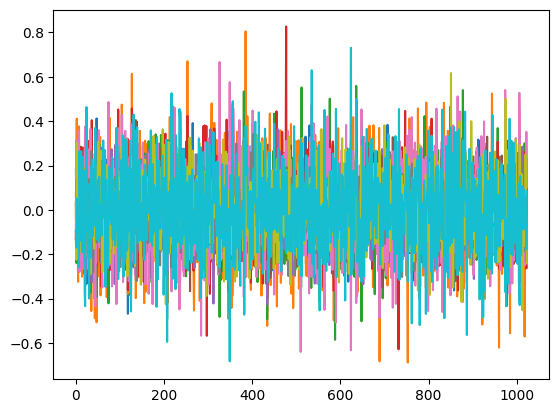

In [97]:
plt.plot(saliency_all_subs_clip[0,:10].T);

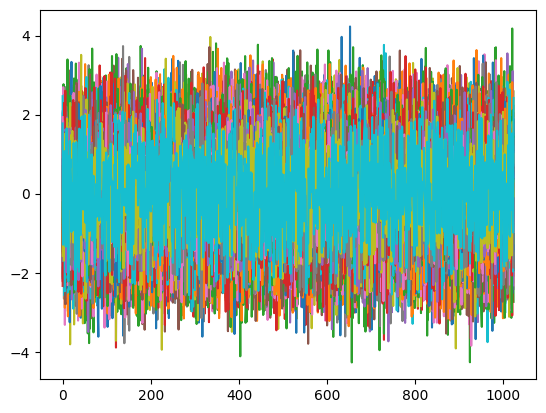

In [78]:
plt.plot(saliency_whitened_all_subs_clip[0,:].T);

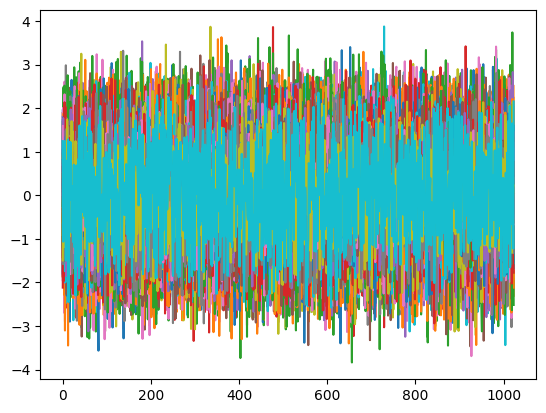

In [79]:
plt.plot(saliency_whitened_all_subs_clip_avg.T);

In [81]:
# np.save('../cache/thingseeg2_preproc/predicted_saliency/saliency_whitened_all_subs_clip_avg.npy', saliency_whitened_all_subs_clip_avg)

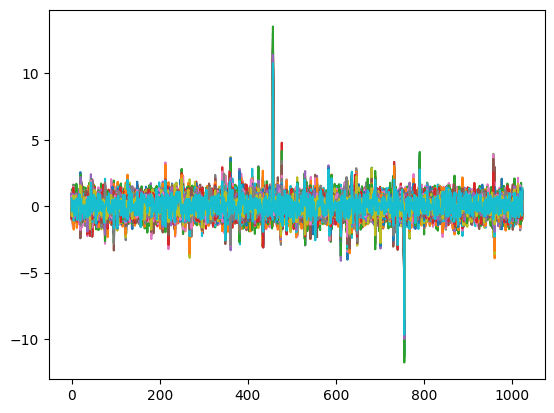

In [87]:
plt.plot(saliency_renormed_all_subs_clip_avg.T);

In [88]:
np.save('../cache/thingseeg2_preproc/predicted_saliency/saliency_renormed_all_subs_clip_avg.npy', saliency_renormed_all_subs_clip_avg)

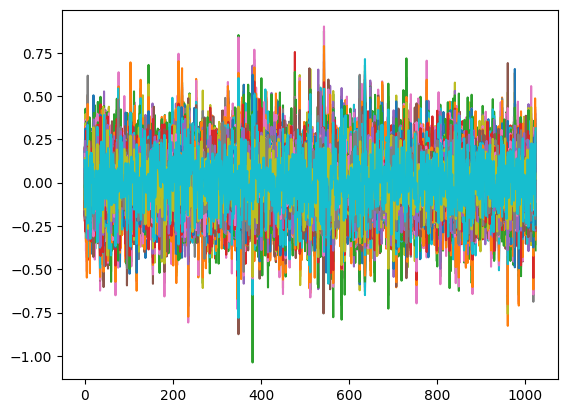

In [94]:
plt.plot(saliency_all_subs_clip_avg[:].T);

In [ ]:
# np.save('../cache/thingseeg2_preproc/predicted_saliency/saliency_all_subs_clip_avg.npy', saliency_all_subs_clip_avg)

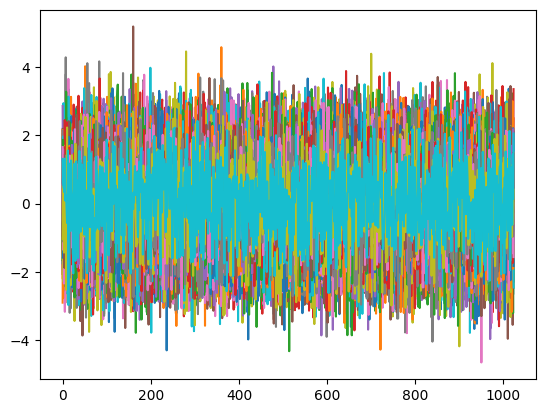

In [74]:
plt.plot(test_latents_whitened.T);

In [76]:
# np.save('../cache/thingseeg2_preproc/predicted_saliency/test_latents_whitened.npy', test_latents_whitened)

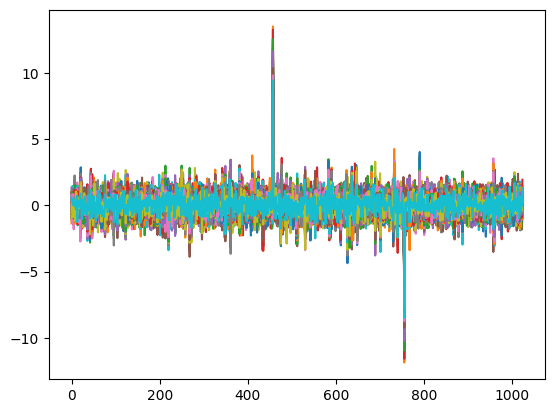

In [77]:
plt.plot(test_latents.T);